In [1]:
## import libraries
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray as rio
import pandas as pd
import glob
import os
import re
import time
from datetime import datetime
import scipy
from tqdm import tqdm
from dask import delayed, compute
from dask.diagnostics import ProgressBar
from dask.distributed import Client, LocalCluster
import shapely
import logging

# import xesmf as xe
import xvec
import ujson
import fsspec
from kerchunk.hdf import SingleHdf5ToZarr
from kerchunk.combine import MultiZarrToZarr

# plotting
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import math



from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import lexcube 
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

import warnings
warnings.filterwarnings("ignore")
from read_check import*

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

metref_colors = [
    (0.00, "#f1f1f1"),  # very low / near zero
    (0.08, "#556691"),
    (0.12, "#112182"),  # dark blue
    (0.22, "#135aba"),
    (0.32, "#449bf3"),  # blue
    (0.42, "#c5eefd"),  # pale blue
    (0.50, "#ffd55c"),  # yellow
    (0.60, "#ff8800"),  # orange
    (0.70, "#f11c00"),  # red
    (0.80, "#ae2716"),  # dark red
    (0.90, "#7e0007"),
    (1.00, "#510056"),  # purple / extreme
]

metref_cmap = LinearSegmentedColormap.from_list(
    "METREF",
    metref_colors,
    N=256
)

GOOD_QFLAGS = [1, 2, 3]

In [2]:
ref_json = "/data/dv-data/cdo_processed/FAPAR/2013/kerchunk/multi/combined_refs.json"
ds = xr.open_dataset(
    "reference://",
    engine="zarr",
    backend_kwargs={"consolidated": False,
                     "storage_options": {"fo": str(ref_json),
                                         "remote_protocol": "file"},
    },
                                                                         
)
ds


<xarray.Dataset> Size: 2GB
Dimensions:         (time: 364, lat: 201, lon: 1501)
Coordinates:
  * time            (time) datetime64[ns] 3kB 2013-01-01 ... 2013-12-31
  * lat             (lat) float64 2kB 10.0 10.05 10.1 10.15 ... 19.9 19.95 20.0
  * lon             (lon) float64 12kB -20.0 -19.95 -19.9 ... 54.9 54.95 55.0
Data variables:
    FAPAR           (time, lat, lon) float64 879MB ...
    quality_flag    (time, lat, lon) float32 439MB ...
    standard_error  (time, lat, lon) float64 879MB ...
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T18:40:24Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [3]:
# load the spatial units

units = gpd.read_parquet("/home/kzakir/dvcube/CDRxClimate/cdrxclimate/cdr_test/mobility_data/spatial_units_with_lat_lon.parquet")
units

# get the bounds from the spatial units
bounds = units.total_bounds  # (minx, miny, maxx, maxy)
min_lon, min_lat, max_lon, max_lat = bounds
print(f"Bounds: min_lon={min_lon}, min_lat={min_lat}, max_lon={max_lon}, max_lat={max_lat}")

Bounds: min_lon=-17.54318619, min_lat=12.30785942, max_lon=-11.34247017, max_lat=16.69207191


In [6]:
if "crs" in ds.data_vars:
    ds = ds.drop_vars("crs")

# # sort coordinates for cleaner downstream behavior
# ds = ds.sortby("lat")
# ds = ds.sortby("lon")

# avoids KeyError when bounds are not exact coordinate labels
lat_mask = (ds["lat"] >= min_lat) & (ds["lat"] <= max_lat)
lon_mask = (ds["lon"] >= min_lon) & (ds["lon"] <= max_lon)
ds = ds.where(lat_mask & lon_mask, drop=True)

# keep monotonic coordinates after subsetting
ds = ds.sortby("lat")
ds = ds.sortby("lon")
print(ds.lat.values[:5], ds.lat.values[-5:], ds.lon.values[:5], ds.lon.values[-5:])

[12.35 12.4  12.45 12.5  12.55] [16.45 16.5  16.55 16.6  16.65] [-17.5  -17.45 -17.4  -17.35 -17.3 ] [-11.55 -11.5  -11.45 -11.4  -11.35]


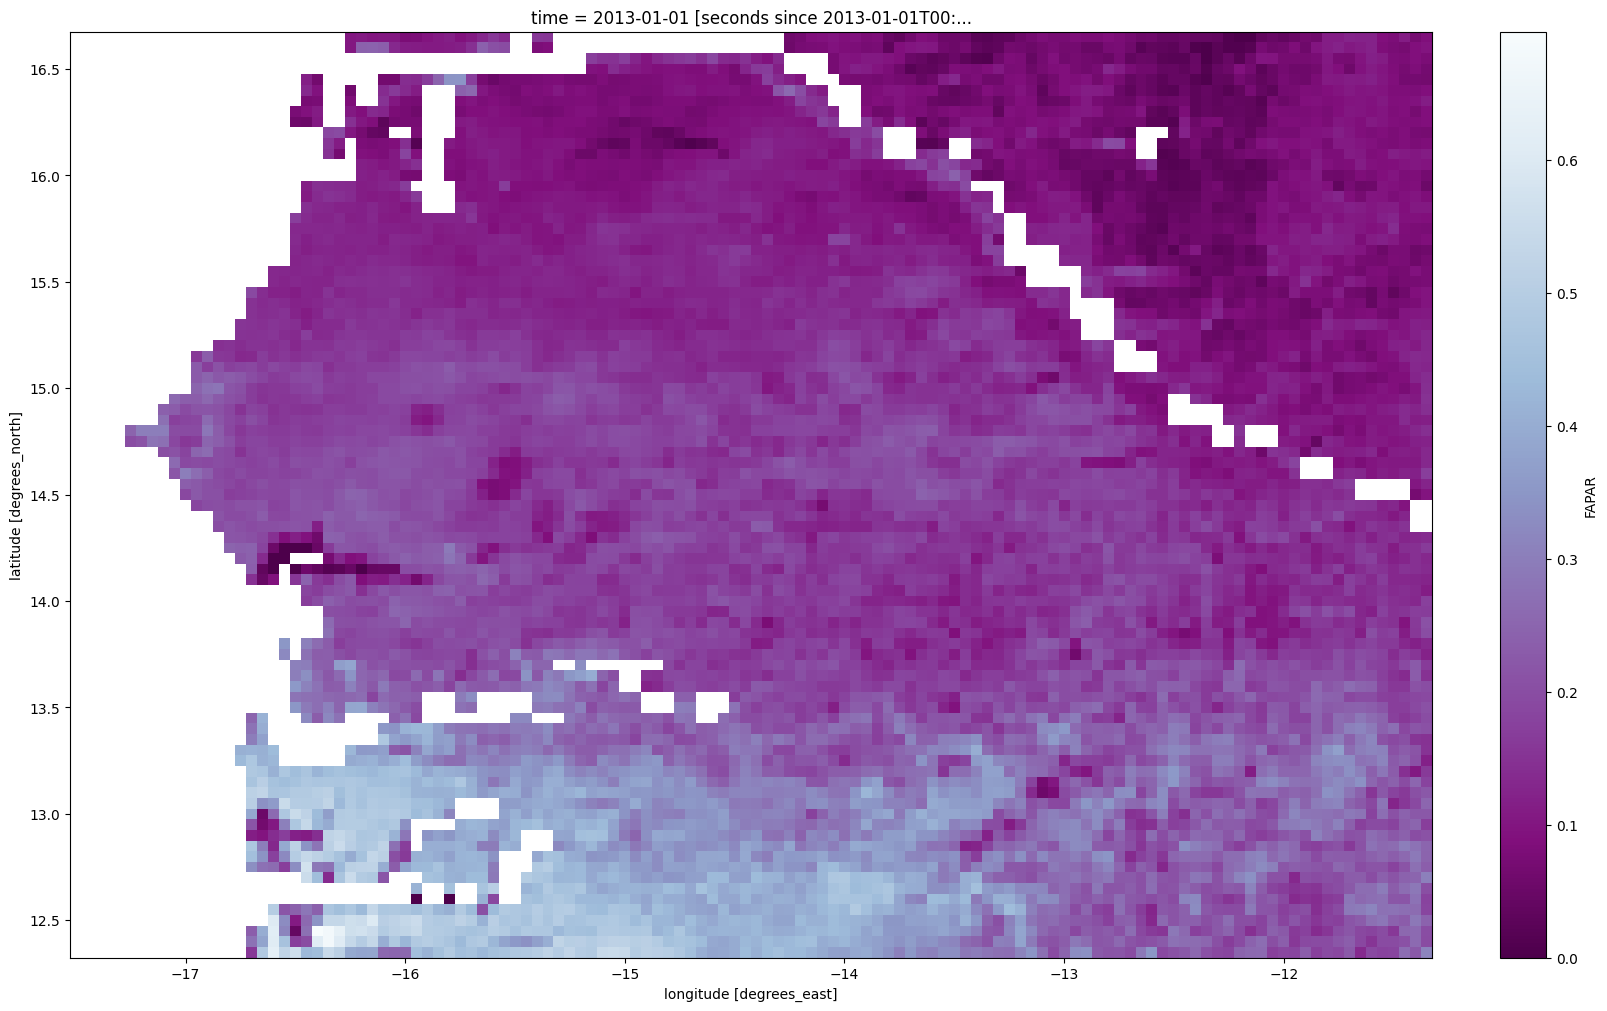

In [8]:
# # Calculate aspect ratio for proper geographic display
# mean_lat = np.radians(float(ds['lat'].mean()))
# aspect_ratio = 1.0 / np.cos(mean_lat)

fig, ax = plt.subplots(figsize=(16, 10), constrained_layout=True)
ds["FAPAR"].isel(time=0).plot(ax=ax, cmap="BuPu_r")
# ax.set_aspect(aspect_ratio)
plt.show()

In [ ]:
def apply_metref_quality_filter(
    ds,
    data_var="METREF",
    qflag_var="quality_flag",
    good_qflags=GOOD_QFLAGS,
    output_var="METREF_q",
):
    """
    Filter METREF using accepted quality flags.
    """

    ds = ds.copy()

    good = ds[qflag_var].isin(
        good_qflags
    )

    ds[output_var] = (
        ds[data_var]
        .where(good)
    )

    ds[output_var].attrs.update(
        ds[data_var].attrs
    )

    ds[output_var].attrs[
        "quality_filter"
    ] = f"Accepted flags: {good_qflags}"

    return ds

In [ ]:
def add_cdr_halfmonth_period(
    ds,
    time_dim="time",
):
    """
    Add CDR-compatible half-month coordinates.

    Period definition
    -----------------
    Day 01-15  -> YYYY-MM-01
    Day 16-end -> YYYY-MM-16

    Adds
    ----
    cdr_period  : actual period timestamp
    period_slot : recurring seasonal slot
                  101  = Jan 01-15
                  116  = Jan 16-end
                  201  = Feb 01-15
                  ...
                  1216 = Dec 16-end
    """

    ds = ds.copy()

    dates = pd.DatetimeIndex(
        ds[time_dim].values
    )

    period_day = np.where(
        dates.day <= 15,
        1,
        16
    )

    cdr_period = pd.to_datetime({
        "year": dates.year,
        "month": dates.month,
        "day": period_day,
    })

    period_slot = (
        dates.month * 100
        + period_day
    )

    ds = ds.assign_coords(
        cdr_period=(
            time_dim,
            cdr_period
        ),
        period_slot=(
            time_dim,
            period_slot
        )
    )

    return ds

In [ ]:
ds = add_cdr_halfmonth_period(ds)
ds

In [ ]:
def aggregate_metref_halfmonth(
    ds,
    data_var="METREF_q",
    keep_count=True,
):
    """
    Aggregate quality-filtered METREF to CDR-compatible
    half-month periods.

    Outputs
    -------
    metref_mean
    metref_min
    metref_max
    metref_p90
    n_good (optional)
    """

    if "cdr_period" not in ds.coords:
        raise ValueError(
            "cdr_period is missing. "
            "Run add_cdr_halfmonth_period() first."
        )

    da = ds[data_var]

    group = da.groupby(
        "cdr_period"
    )

    mean = group.mean(
        "time",
        skipna=True
    )

    minimum = group.min(
        "time",
        skipna=True
    )

    maximum = group.max(
        "time",
        skipna=True
    )

    p90 = group.quantile(
        0.90,
        dim="time",
        skipna=True
    )

    # Remove scalar quantile coordinate
    if "quantile" in p90.coords:
        p90 = p90.reset_coords(
            "quantile",
            drop=True
        )

    result = xr.Dataset({
        "metref_mean": mean,
        "metref_min": minimum,
        "metref_max": maximum,
        "metref_p90": p90,
    })

    if keep_count:
        result["n_good"] = (
            da.notnull()
            .groupby("cdr_period")
            .sum("time")
        )

    # recurring seasonal slot for aggregated periods
    dates = pd.DatetimeIndex(
        result["cdr_period"].values
    )

    slot = (
        dates.month * 100
        + dates.day
    )

    result = result.assign_coords(
        period_slot=(
            "cdr_period",
            slot
        )
    )

    result.attrs[
        "temporal_aggregation"
    ] = "CDR-compatible half-month"

    result.attrs[
        "period_definition"
    ] = (
        "01 = days 1-15; "
        "16 = days 16-end of month"
    )

    return result

In [ ]:
ds_halfmonth = (
    aggregate_metref_halfmonth(
        ds,
        data_var="METREF_q"
    )
)

In [ ]:
ds_halfmonth
#assogn crs
ds_halfmonth = ds_halfmonth.rio.write_crs("EPSG:4326", inplace=True)